<div style="float: block; text-align: center; line-height: 1.7em">
    <span style="font-size: 2em; font-weight: bold"> Fatigue-Sleepiness in Irregular Workloads for Pilots </span><br>
    <span style="font-size: 1.5em; font-weight: bold"> Statistical Modelling - Perceived Excessive Sleepiness </span><br>
</div>

----

---

# 1. Loading Libraries and Packages

In [40]:
import os                                            # system library
import pandas as pd                                  # library to handle databases
import numpy as np                                   # library to handle arrays and matrices
import matplotlib.pyplot as plt                      # graphical package
import seaborn as sns                                # beautification graphical package
from IPython.display import display, HTML

os.environ['R_HOME'] = "C:/PROGRA~1/R/R-44~1.2"      # Necessary to configure R_HOME path
from pymer4.models import Lmer                       # Package for statistical modelling

import rpy2.robjects as ro                           # Forcing to UTF-8 locale
ro.r('Sys.setlocale("LC_ALL", "English_United States.UTF-8")')

from sklearn.metrics import roc_auc_score, roc_curve, classification_report, accuracy_score, confusion_matrix, auc
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

----

# 2. Reading Pre-Processed Data

In [2]:
file = os.path.join('data','slp_wrk_mdl_train.csv')
try:
    df = pd.read_csv(file)
    print('-----------------------------------------------')
    print(f"\033[93mSuccess Data file read!\033[0m")
    print('-----------------------------------------------')
    # display(df.head(3))
except Exception as e:
    print('-----------------------------------------------')
    print(f"\033[91mAn error occurred:\033[0m {e}")
    print('-----------------------------------------------')

-----------------------------------------------
Success Data file read!
-----------------------------------------------


----

# 3. Verifying for Null rows

In [3]:
df['Sleep_quality'] = pd.to_numeric(df['Sleep_quality'], errors = 'coerce')
wsm = df.isna().sum()
display(pd.DataFrame(wsm).T)

,Id,TPFS_slp,duty_moment,DMod_slp,sleep_dev,Sleep_quality,time_awake,sleep_duration,age,kssd
0,0,0,0,0,0,24,4,0,0,0


* As we can see above for covariates time_awake and sleep duration there are some null rows, so these rows containing null values will be taken away.

In [4]:
df = df.dropna()

wsm = df.isna().sum()
display(pd.DataFrame(wsm).T)

,Id,TPFS_slp,duty_moment,DMod_slp,sleep_dev,Sleep_quality,time_awake,sleep_duration,age,kssd
0,0,0,0,0,0,0,0,0,0,0


* Now, there is no longer null rows!

---

# 4. Scalling some covariates

To avoid scalling bias in the model, we will rescalling some continuous covariates.

In [5]:
df[['Sleep_quality','time_awake','sleep_duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_quality,1026.0,7.321637,1.696441,2.000000,6.000000,8.000,9.000000,10.000000
time_awake,1026.0,3.872498,3.510890,0.250000,1.500000,2.375,5.016667,17.400000
sleep_duration,1026.0,7.178736,1.792701,2.466667,6.129167,7.200,8.383333,12.416667


Above is shown some descriptive statistics of the ordinal and continuous covariates, based on the covariate statistics we propose the max-min standardization.

In [6]:
df['Sleep_quality'] = df['Sleep_quality']/(df['Sleep_quality'].max()-df['Sleep_quality'].min())
df['time_awake'] = df['time_awake']/(df['time_awake'].max()-df['time_awake'].min())
df['sleep_duration'] = df['sleep_duration']/(df['sleep_duration'].max()-df['sleep_duration'].min())

---

# 5. Preliminary Regression Analysis

Once we have a repeated measure design or a panel like data, we choose a mixed logistic model given by:

<p style="text-align: center;"> $g(x_{ij},\beta_{0i},\beta_1, \beta_s) = \beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s$  (level 1) </p>
<p style="text-align: center;"> $\beta_{0i} = \beta_0 + \alpha_i$  (level 1, random intercept) </p>

where $\alpha_i \sim N(0,\sigma_\alpha^2)$ .

with $\alpha_i$ representing the random intercept due to participant variability and $\beta_0$ the intercept or baselines.

The logistic link function os given by:

<p style="text-align: center;"> $$g(x_{ij},\beta_{0i},\beta_1, \beta_s) = ln\left[\frac{\pi(x_{ij},\beta_{0i},\beta_1, \beta_s)}{1-\pi(x_{ij},\beta_{0i},\beta_1, \beta_s)}\right]$$ </p>

with, 

<p style="text-align: center;"> $$\pi(x_{ij},\beta_{0i},\beta_1, \beta_s) = \frac{e^{\beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s}}{1+e^{\beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s}}$$</p>


## 5.1. Function to codify the covariates in pymer standards

In [7]:
def get_formula(covariates, target, prnt = False):
    formula = f'{target}~'
    for cvt in covariates:
        formula += cvt+'+'
    formula = formula[:-1]
    if prnt:
        print(f'formula:\n{formula}')
    return formula

## 5.2. First Iteration

In [11]:
covariates = ['TPFS_slp','duty_moment','DMod_slp','sleep_dev','Sleep_quality','time_awake','sleep_duration','age']

formula = get_formula(covariates, 'kssd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')


model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+sleep_dev+Sleep_quality+time_awake+sleep_duration+age+(1|Id)
----------------------------------------------------------------------------------------------------------
Model failed to converge with max|grad| = 0.0162019 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+sleep_dev+Sleep_quality+time_awake+sleep_duration+age+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -372.246 	 AIC: 768.492

Random effects:

           Name    Var    Std
Id  (Intercept)  0.442  0.665

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.029,-0.294,2.353,0.675,2.800,0.745,10.521,0.737,0.427,0.913,1.524,0.127,
TPFS_slpem+eve,1.105,0.630,1.579,0.242,3.018,1.878,4.851,0.751,0.652,0.829,4.562,0.000,***
TPFS_slpNI,1.542,0.931,2.154,0.312,4.675,2.536,8.618,0.824,0.717,0.896,4.943,0.000,***
duty_momentmiddle,-1.404,-1.866,-0.942,0.236,0.246,0.155,0.390,0.197,0.134,0.281,-5.956,0.000,***
duty_momentstart,-2.585,-3.136,-2.033,0.281,0.075,0.043,0.131,0.070,0.042,0.116,-9.190,0.000,***
DMod_slpni,0.653,0.218,1.087,0.222,1.921,1.244,2.966,0.658,0.554,0.748,2.944,0.003,**
sleep_dev,0.223,-0.325,0.771,0.280,1.250,0.723,2.162,0.556,0.420,0.684,0.798,0.425,
Sleep_quality,-2.712,-3.781,-1.644,0.545,0.066,0.023,0.193,0.062,0.022,0.162,-4.974,0.000,***
time_awake,0.781,-0.273,1.834,0.537,2.183,0.761,6.257,0.686,0.432,0.862,1.453,0.146,
sleep_duration,-1.113,-2.487,0.261,0.701,0.329,0.083,1.299,0.247,0.077,0.565,-1.587,0.112,


As we can see above, for the first iteration, some covariates have no statistically significant effect on perception of sleepiness. However from exploratory data analysis when assessed isolated they present some effects on perception of sleepiness. So, the following transformations is proposed:

>- For **time_awake** we transform this covariate into an indicator of time awake before duty greater than 10 hours.
>
>- For **sleep duration** we transform this covariate in an indicator of sleep duration less than 5 hours.
>
>- For **sleep devaition**, we will not explore further this covariate for perception of sleepiness.

## 5.3. Second Iteration

### 5.3.1. Applying the transformations proposed

In [12]:
df['sleep_dur'] = np.where(df['sleep_duration']< (5/(12.417-2.467)), 1, 0)
df['t_awake'] = np.where(df['time_awake'] > (10/(17.400000-0.250000)), 1, 0)

### 5.3.2. Running the second iteration

In [16]:
covariates = ['TPFS_slp','duty_moment','DMod_slp','Sleep_quality','sleep_dur','t_awake','age']

formula = get_formula(covariates, 'kssd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')

model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+Sleep_quality+sleep_dur+t_awake+age+(1|Id)
----------------------------------------------------------------------------------------------------------
Model failed to converge with max|grad| = 0.0141925 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+Sleep_quality+sleep_dur+t_awake+age+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -370.566 	 AIC: 763.132

Random effects:

           Name   Var    Std
Id  (Intercept)  0.38  0.617

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.614,-0.350,1.578,0.492,1.847,0.705,4.843,0.649,0.413,0.829,1.248,0.212,
TPFS_slpem+eve,1.118,0.660,1.576,0.234,3.058,1.934,4.835,0.754,0.659,0.829,4.782,0.000,***
TPFS_slpNI,1.493,0.900,2.086,0.303,4.449,2.459,8.052,0.816,0.711,0.890,4.933,0.000,***
duty_momentmiddle,-1.407,-1.869,-0.945,0.236,0.245,0.154,0.389,0.197,0.134,0.280,-5.973,0.000,***
duty_momentstart,-2.593,-3.141,-2.046,0.279,0.075,0.043,0.129,0.070,0.041,0.114,-9.288,0.000,***
DMod_slpni,0.631,0.198,1.064,0.221,1.879,1.218,2.897,0.653,0.549,0.743,2.854,0.004,**
Sleep_quality,-2.892,-3.908,-1.875,0.519,0.055,0.020,0.153,0.053,0.020,0.133,-5.576,0.000,***
sleep_dur,0.653,0.102,1.205,0.281,1.922,1.108,3.335,0.658,0.526,0.769,2.323,0.020,*
t_awake,0.728,0.058,1.398,0.342,2.071,1.060,4.046,0.674,0.515,0.802,2.131,0.033,*
agemiddle,0.570,-0.008,1.147,0.295,1.767,0.992,3.150,0.639,0.498,0.759,1.931,0.053,.


>- As we can see above after the proposed transformations, almost all the covariates presents statistical significance at the level of 95%, except agemiddle, an indicator of participants with ages between 35 and 45 years, presenting the highest p-value or the least significant covariate. 
>
>- So, we will remove this covariate in the next iteration.

## 5.4. Third Iteration

In [19]:
covariates = ['TPFS_slp','duty_moment','DMod_slp','Sleep_quality','sleep_dur','t_awake']

formula = get_formula(covariates, 'kssd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')

model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+Sleep_quality+sleep_dur+t_awake+(1|Id)
----------------------------------------------------------------------------------------------------------
Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: kssd~TPFS_slp+duty_moment+DMod_slp+Sleep_quality+sleep_dur+t_awake+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -372.330 	 AIC: 764.659

Random effects:

           Name    Var    Std
Id  (Intercept)  0.456  0.675

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.755,-0.209,1.718,0.492,2.127,0.811,5.576,0.680,0.448,0.848,1.534,0.125,
TPFS_slpem+eve,1.113,0.655,1.572,0.234,3.044,1.925,4.814,0.753,0.658,0.828,4.761,0.000,***
TPFS_slpNI,1.500,0.906,2.094,0.303,4.481,2.473,8.117,0.818,0.712,0.890,4.947,0.000,***
duty_momentmiddle,-1.412,-1.874,-0.950,0.236,0.244,0.153,0.387,0.196,0.133,0.279,-5.987,0.000,***
duty_momentstart,-2.589,-3.136,-2.042,0.279,0.075,0.043,0.130,0.070,0.042,0.115,-9.278,0.000,***
DMod_slpni,0.621,0.187,1.055,0.222,1.860,1.205,2.872,0.650,0.547,0.742,2.802,0.005,**
Sleep_quality,-2.873,-3.899,-1.847,0.523,0.057,0.020,0.158,0.053,0.020,0.136,-5.489,0.000,***
sleep_dur,0.697,0.147,1.247,0.281,2.008,1.159,3.482,0.668,0.537,0.777,2.484,0.013,*
t_awake,0.764,0.088,1.441,0.345,2.148,1.091,4.227,0.682,0.522,0.809,2.213,0.027,*


>- Now as we can see, all the covariates present statistically significant effects at the p-level of 0.05 or 5%. 

---

# 6. Model Assessment

## 6.1. Overdispersion Ratio

The Overdispersion ratio for binomial model is given by:

$$ OD = \frac{ \sum_{i=1}^{n} r_i^2}{df}$$

where $r_i^2$ is the squared sum of residuals and $df$ is the degrees of freedom of the model.

In [20]:
res = model_LME.residuals
pearson = np.sum((res)**2)
df_resid = model_LME.data.shape[0] - len(model_LME.fixef)
overdispersion_ratio = pearson / df_resid

print('-------------------------------')
print(f'\033[91m OD = {round(overdispersion_ratio, 3)}\033[0m')
print('-------------------------------')

-------------------------------
 OD = 0.702
-------------------------------


As we can see $OD<1$, meaning underdispersion, in other words:

>- The model's predicted variance is slightly larger than the observed variance
>
>- Possibly the random effects structure is appropriate
>
>- The predictor explains a good amount of the variability of the model
>
>- The random intercept variance is 0.456 with SD = 0.675, that looks reasonable. In overdispersion cases the random intercept variance is near zero or inflated  

Overall, this check means that the model is not miss-specified, in case of overdispersion another model must be choosen.

## 6.2. Performance Analysis

In [41]:
# Getting predictions from training set, evaluated by the model
df_res = pd.DataFrame({'y_that':list(model_LME.fits),'y':df.kssd})

### 6.2.1. Curve ROC and AUC

In [42]:
# Computing ROC curve
fpr, tpr, _ = roc_curve(df_res['y'], df_res['y_that']-min(df_res['y_that']))
roc_auc = auc(fpr, tpr)

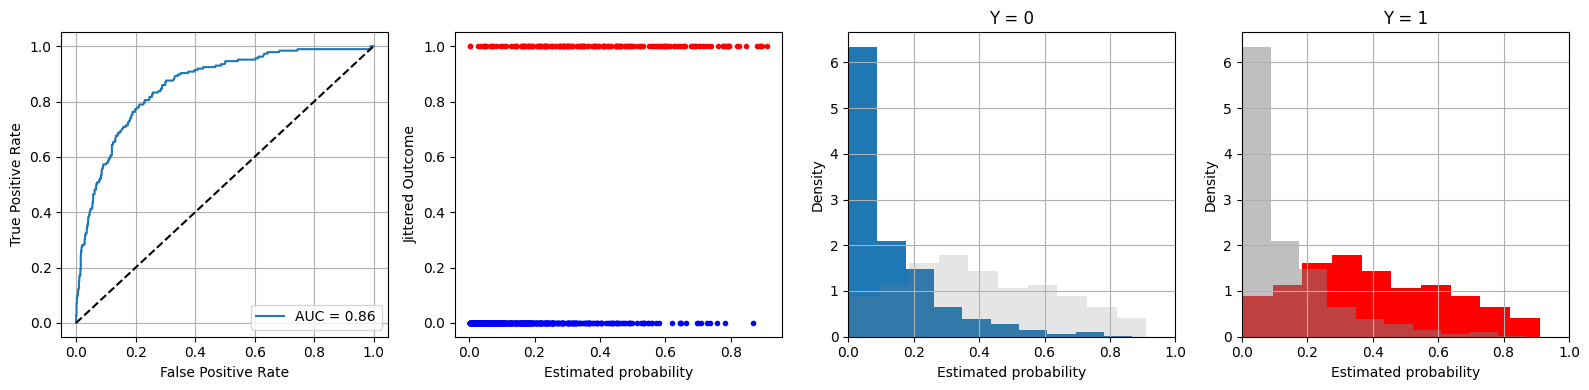

In [43]:
fig, ax = plt.subplots(1,4, figsize = (16,4))

ax[0].plot(fpr, tpr, label=f'AUC = {str(round(roc_auc, 2))}')
ax[0].plot([0,1], [0,1],'k--',)
ax[0].legend(loc='lower right')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].grid(True)

ax[1].plot(df_res.y_that[df_res.y == 0], df_res.y[df_res.y == 0],'.' ,color = 'blue')
ax[1].plot(df_res.y_that[df_res.y == 1], df_res.y[df_res.y == 1],'.',color = 'red')
ax[1].set_xlabel('Estimated probability')
ax[1].set_ylabel('Jittered Outcome')

ax[2].hist(df_res.y_that[df_res.y == 0], density = True)
ax[2].hist(df_res.y_that[df_res.y == 1], density = True, color = 'gray', alpha=0.2)
ax[2].set_xlabel('Estimated probability')
ax[2].set_ylabel('Density')
ax[2].set_title('Y = 0')
ax[2].set_xlim(0,1)
ax[2].grid(True)

ax[3].hist(df_res.y_that[df_res.y == 1], density = True, color = 'red')
ax[3].hist(df_res.y_that[df_res.y == 0], density = True, color = 'gray', alpha=0.5)
ax[3].set_xlabel('Estimated probability')
ax[3].set_ylabel('Density')
ax[3].set_title('Y = 1')
ax[3].set_xlim(0,1)
ax[3].grid(True)

plt.tight_layout()
plt.show()
fig.savefig('figures/performance_model_slp.png')

Figures above show some KPIs for model assesment, so,

> * The leftmost figure shows the ROC curve and the AUC metric. As we can see, the value of AUC is 0.86 showing that the model can be considered an excellent discriminator (Following Hosmer and Lemeshow (2003)).
>
> * The jittered outcome figure presents how the predicted positives and negatives distributes along the estimated probability domain, with the red points representing the indicator of perception of excessive sleepiness while the blue ones representing the opposite. As we can see as expected the blue points concentrates toward lower estimated probability and the red points is well distributed along the estimated probability domain.
>
> * The two figures at the right part of the pannel presents the density estimate for the model predictions of perception of no extreme condition (Y=0) and extreme conditions (Y=1) of sleepiness. We can see the same as interpreted for the jittered outcome.  

### 6.2.2. Confusion Matrix & Callibration

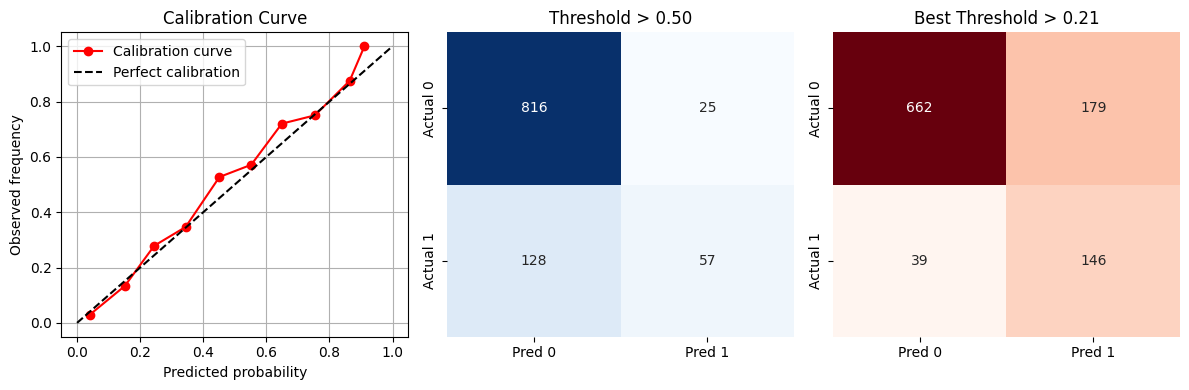

In [64]:
y_pred_opt = (np.array(y_prob) >= 0.50).astype(int)
cm = confusion_matrix(y_true, y_pred_opt)
cm_prev = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])

# Youden J statistic
j_scores = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]
#print(f"Optimal threshold (Youden's J): {best_thresh:.3f}")

# Confusion matrix at optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_true, y_pred_opt)
#print("Confusion Matrix at Optimal Threshold:")
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
#print(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1']))

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))
ax[0].plot(prob_pred, prob_true, marker='o', label='Calibration curve', color = 'red')
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax[0].set_xlabel('Predicted probability')
ax[0].set_ylabel('Observed frequency')
ax[0].set_title('Calibration Curve')
ax[0].legend()
ax[0].grid(True)

sns.heatmap(cm_prev, annot=True, fmt='d', cmap='Blues', cbar=False, ax = ax[1])
ax[1].set_title(f'Threshold > 0.50')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar = False, ax = ax[2])
ax[2].set_title(f'Best Threshold > {best_thresh:.2f}')
plt.tight_layout()
plt.show()

Above is shown the calibration curve as well as the confusion matrix using thresholds greater than 0.5 and the best threshold pointed by Youden's j statitics.

> * As we can see the calibration curve (red curve in the left figure), is near the 1:1 line, showing that the model is well calibrated and that the probability output by the model is reliable.
>
> * The confusion matrix shows that the model is a good discriminator for the class 0 but not a good discrimator for class 1 (the interest class), considering the standard threshold (0.5) leading to many false negatives.
>
> * After applying the best threshold, the model describes better the class of interest, however leading to a rise in false positives.   

In [67]:
print('----------------------------------------')
print(f'Accuracy score: {accuracy_score(y_true, y_pred_opt):.2f}')
print('----------------------------------------')

----------------------------------------
Accuracy score: 0.79
----------------------------------------


---

# 7. Model's coefficient interpretation

In [86]:
coef = mdf.loc[:,['OR_2.5_ci','OR','OR_97.5_ci']]
coef.head()

,OR_2.5_ci,OR,OR_97.5_ci
(Intercept),0.811,2.127,5.576
TPFS_slpem+eve,1.925,3.044,4.814
TPFS_slpNI,2.473,4.481,8.117
duty_momentmiddle,0.153,0.244,0.387
duty_momentstart,0.043,0.075,0.130
